In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


from sklearn.datasets import fetch_openml
housing = fetch_openml(name="house_prices", as_frame=True) 
df = housing.frame

# Target variable is 'SalePrice'
y = df['SalePrice']
# Drop ID column (useless for prediction)
X = df.drop(columns=['SalePrice', 'Id']) 



In [2]:
# Selecting 5 highly impactful features
feature_cols = ['OverallQual', 'GrLivArea', 'GarageCars', 'YearBuilt', 'TotalBsmtSF']
X = df[feature_cols]

print("Selected Features:")
print(X.head())

Selected Features:
   OverallQual  GrLivArea  GarageCars  YearBuilt  TotalBsmtSF
0            7       1710           2       2003          856
1            6       1262           2       1976         1262
2            7       1786           2       2001          920
3            7       1717           3       1915          756
4            8       2198           3       2000         1145


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")

Training set size: 1168 rows
Test set size: 292 rows


In [4]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model training complete!")
print(f"Intercept: ${model.intercept_:,.2f}")
print("\nFeature Coefficients (impact on price):")
for col, coef in zip(feature_cols, model.coef_):
    print(f"  {col}: ${coef:,.2f}")

Model training complete!
Intercept: $-694,533.36

Feature Coefficients (impact on price):
  OverallQual: $20,392.51
  GrLivArea: $48.81
  GarageCars: $15,144.24
  YearBuilt: $315.92
  TotalBsmtSF: $25.37


In [5]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE (Root Mean Squared Error): ${rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

RMSE (Root Mean Squared Error): $39,763.30
R² Score: 0.7939


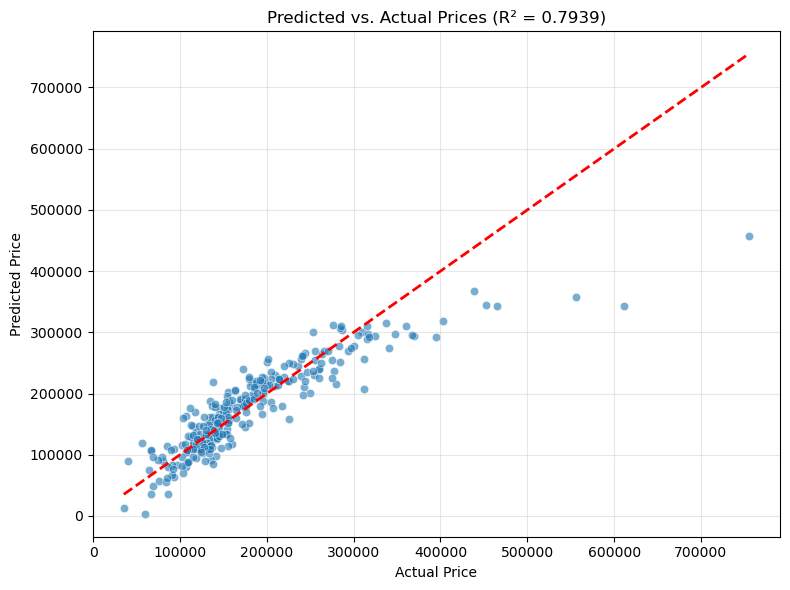

In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='w', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Predicted vs. Actual Prices (R² = {r2:.4f})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


My linear regression model achieved an R² score of [insert your R² value here].

In plain English, R² tells us how much better my model is at predicting house prices compared to just guessing the average price every single time.

If R² = 0, my model is useless — it's no better than saying "every house costs the average price."
If R² = 1, my model is perfect — it predicts every single price exactly right (which never happens in real life).

For example, if my R² is 0.75, I would explain it like this:  
"75% of the differences in house prices can be explained by just these 5 features (overall quality, living area, garage capacity, year built, and basement size). The remaining 25% depends on other things I didn't measure, like location, school districts, or how well the house is decorated."

In real estate, an R² above 0.7 is generally considered a pretty solid model!